<a href="https://colab.research.google.com/github/Syeda-Rb-47/Building-GlueScore--An-Interpretable-Glue-Likeness-Scoring-Pipeline/blob/main/6_Validation_and_Supporting_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTS

In [ ]:
# Importing required libraries and mounting DRIVE.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Defining path of datasets.
DRIVE_DIR = "/content/drive/MyDrive/Thesis Datasets"
SAVE_DIR = "/content/drive/MyDrive/Thesis Datasets"

In [ ]:
# Loading the datasets.
test_df   = pd.read_csv(DRIVE_DIR + "/Test_split.csv")
train_df  = pd.read_csv(DRIVE_DIR + "/Train_split.csv")   # needed to re-train ML models
scaler    = joblib.load(DRIVE_DIR + "/Fitted_Scaler.pkl")
desc_cols = pd.read_csv(DRIVE_DIR + "/Descriptor_list.csv")["Descriptor"].tolist()
weight_df = pd.read_csv(DRIVE_DIR + "/GlueScore_Weight_Table.csv")

weights = weight_df.set_index("Descriptor")["Weight"]
signs   = weight_df.set_index("Descriptor")["Sign"]

meta_cols = ["Master_ID", "Source_ID", "Label", "Canonical_SMILES", "StdInChIKey"]
meta_cols = [c for c in meta_cols if c in test_df.columns]

print("Records of Datasets loaded\n")
print("Test set  :", len(test_df), " | Glues:", (test_df["Label"]==1).sum(), " | Background:", (test_df["Label"]==0).sum())
print("Train set :", len(train_df), " | Glues:", (train_df["Label"]==1).sum(), " | Background:", (train_df["Label"]==0).sum())
print("Descriptors:", desc_cols)
print("\nWeight table:")
print(weight_df.to_string(index=False))

Records of Datasets loaded

Test set  : 748  | Glues: 325  | Background: 423
Train set : 2990  | Glues: 1298  | Background: 1692
Descriptors: ['fr_NH1', 'NumHeterocycles', 'NOCount', 'RingCount', 'NumAromaticRings', 'fr_aniline', 'FractionCSP3']

Weight table:
      Descriptor   Delta  Weight  Sign    Direction
          fr_NH1  1.0824  1.0824     1 Glues_Higher
 NumHeterocycles  1.0300  1.0300     1 Glues_Higher
       RingCount  0.9247  0.9247     1 Glues_Higher
         NOCount  0.8410  0.8410     1 Glues_Higher
NumAromaticRings  0.8391  0.8391     1 Glues_Higher
      fr_aniline  0.6495  0.6495     1 Glues_Higher
    FractionCSP3 -0.5474  0.5474    -1  Glues_Lower


STANDARDIZING TEST SET

In [ ]:
# Standardizing Test Set (using scaler fit on train, from Step 5)
z_test = pd.DataFrame(scaler.transform(test_df[desc_cols].values), columns=desc_cols, index=test_df.index)
z_test["Label"] = test_df["Label"].values

print("Test Set Standardized\n")
print(z_test[desc_cols].head())

Test Set Standardized

     fr_NH1  NumHeterocycles   NOCount  RingCount  NumAromaticRings  \
0 -0.139727         0.030217 -0.026121  -0.353185         -0.835326   
1 -1.084940        -0.654248 -1.499715  -0.893626         -0.068948   
2 -0.139727         2.768078  1.742193   2.889462          0.697429   
3 -0.139727         1.399147  2.331631   0.187257         -0.835326   
4 -1.084940        -1.338713 -0.320839  -1.974508         -1.601703   

   fr_aniline  FractionCSP3  
0   -0.731825     -0.745218  
1   -0.731825     -0.362515  
2    0.272377      0.922622  
3   -0.731825      0.102290  
4   -0.731825      2.856689  


CALCULATING GLUESCORE (RAW)

In [ ]:
# Calculating Raw GlueScore on Test Set (held-out evaluation)
weighted_z_test = z_test[desc_cols].multiply(weights * signs, axis=1)
test_df = test_df.copy()
test_df["GlueScore_raw"] = weighted_z_test.sum(axis=1)

print("Raw GlueScore on TEST SET (held-out)\n")
print("Glues      — mean:", round(test_df[test_df["Label"]==1]["GlueScore_raw"].mean(), 4))
print("Background — mean:", round(test_df[test_df["Label"]==0]["GlueScore_raw"].mean(), 4))
print("Glues      — median:", round(test_df[test_df["Label"]==1]["GlueScore_raw"].median(), 4))
print("Background — median:", round(test_df[test_df["Label"]==0]["GlueScore_raw"].median(), 4))

Raw GlueScore on TEST SET (held-out)

Glues      — mean: 2.7179
Background — mean: -2.4931
Glues      — median: 2.6138
Background — median: -2.8579


CONVERTING GLUESCORE (RAW) TO PERCENTILE (0-100)

In [ ]:
# Percentile Conversion (0-100 scale) on Test Set
test_df["GlueScore"] = test_df["GlueScore_raw"].rank(pct=True) * 100

print("GlueScore (0-100 Percentile Scale) on TEST SET\n")
print("Glues      — mean   :", round(test_df[test_df["Label"]==1]["GlueScore"].mean(), 1))
print("Background — mean   :", round(test_df[test_df["Label"]==0]["GlueScore"].mean(), 1))
print("Glues      — median :", round(test_df[test_df["Label"]==1]["GlueScore"].median(), 1))
print("Background — median :", round(test_df[test_df["Label"]==0]["GlueScore"].median(), 1))

GlueScore (0-100 Percentile Scale) on TEST SET

Glues      — mean   : 70.7
Background — mean   : 34.2
Glues      — median : 74.7
Background — median : 29.7


VISUALIZING AND VALIDATING SCORING FRAMEWORK

/tmp/ipykernel_2548/2557384742.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x="Class", y="GlueScore", ax=axes[1],


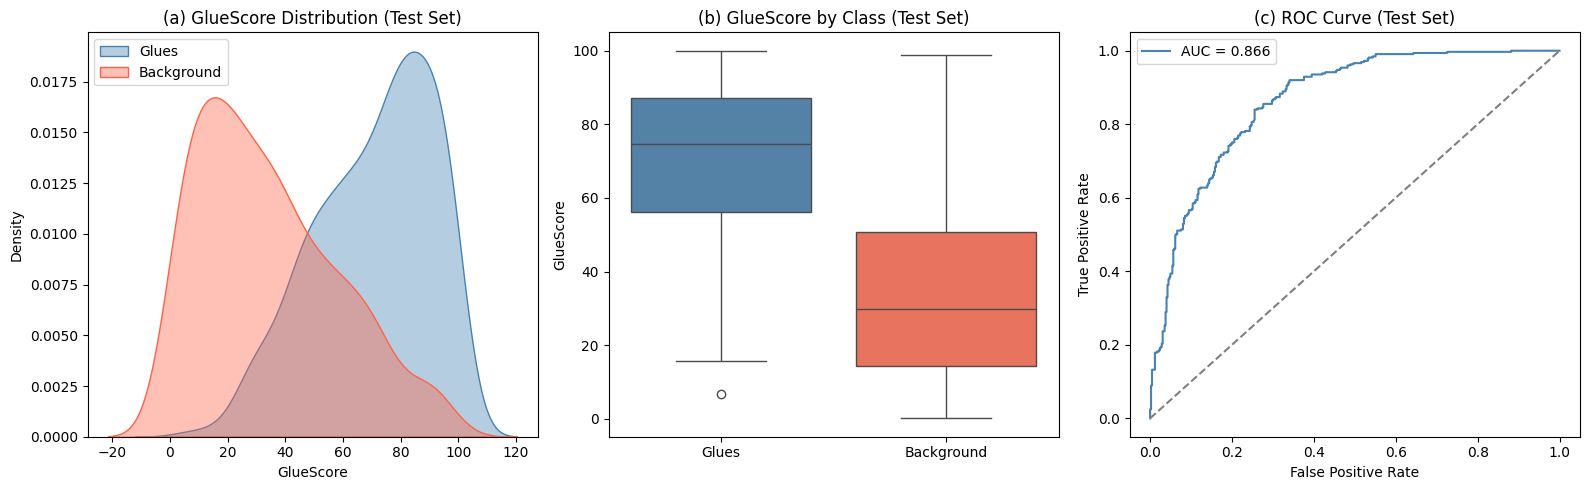

Test Set AUC: 0.866


In [ ]:
# Visualizing GlueScore (Test Set) and Calculating AUC.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.kdeplot(test_df[test_df["Label"]==1]["GlueScore"], ax=axes[0],
            label="Glues", color="steelblue", fill=True, alpha=0.4)
sns.kdeplot(test_df[test_df["Label"]==0]["GlueScore"], ax=axes[0],
            label="Background", color="tomato", fill=True, alpha=0.4)
axes[0].set_xlabel("GlueScore")
axes[0].set_ylabel("Density")
axes[0].set_title("(a) GlueScore Distribution (Test Set)")
axes[0].legend()

plot_df          = test_df[["Label", "GlueScore"]].copy()
plot_df["Class"] = plot_df["Label"].map({1: "Glues", 0: "Background"})
sns.boxplot(data=plot_df, x="Class", y="GlueScore", ax=axes[1],
            palette={"Glues": "steelblue", "Background": "tomato"})
axes[1].set_title("(b) GlueScore by Class (Test Set)")
axes[1].set_xlabel("")
axes[1].set_ylabel("GlueScore")

fpr, tpr, _ = roc_curve(test_df["Label"], test_df["GlueScore"])
auc = roc_auc_score(test_df["Label"], test_df["GlueScore"])
axes[2].plot(fpr, tpr, color="steelblue", label="AUC = " + str(round(auc, 3)))
axes[2].plot([0, 1], [0, 1], color="grey", linestyle="--")
axes[2].set_xlabel("False Positive Rate")
axes[2].set_ylabel("True Positive Rate")
axes[2].set_title("(c) ROC Curve (Test Set)")
axes[2].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR + "/GlueScore_Evaluation_Plots.png", dpi=150, bbox_inches="tight")
plt.show()

print("Test Set AUC:", round(auc, 3))

In [ ]:
# Ranked GlueScore Table for Test set (Descending, Glues Highlighted).

sorted_test = test_df[meta_cols + ["GlueScore_raw", "GlueScore"]].copy()
sorted_test = sorted_test.sort_values("GlueScore", ascending=False).reset_index(drop=True)

print("Top 10 GlueScore Rankings (Test Set, Descending)\n")
print(sorted_test.head(10).to_string(index=False))
print("\n")

def highlight_glues(row):
    color = "background-color: lightgreen" if row["Label"] == 1 else ""
    return [color] * len(row)

styled_table = sorted_test.head(30).style.apply(highlight_glues, axis=1)
styled_table

Top 10 GlueScore Rankings (Test Set, Descending)

 Master_ID     Source_ID  Label                                                                                                                     Canonical_SMILES                 StdInChIKey  GlueScore_raw  GlueScore
        43            43      1                      CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCN(CC(=O)NCCOCCOCCOCCNc5cccc6c5C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cn3)nc2n(C2CCCC2)c1=O UTSBHEVQCONLCR-UHFFFAOYSA-N      14.496357 100.000000
        42            42      1                   CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCN(CC(=O)NCCOCCOCCOCCNC(=O)COc5cccc6c5CN(C5CCC(=O)NC5=O)C6=O)CC4)cn3)nc2n(C2CCCC2)c1=O KMPGLIUMPOPVBR-UHFFFAOYSA-N      14.038563  99.866310
       483           484      1                                CCn1nc(C2CC2)cc1Nc1nc(C(=O)NCCCCCc2cccc3c2CN(C2CCC(=O)NC2=O)C3=O)nc2[nH]c3cc(-c4c(C)noc4C)c(OC)cc3c12 UZXANFBIRSYHGO-UHFFFAOYSA-N      13.979458  99.732620
      1521          1526      1             CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCN

,Master_ID,Source_ID,Label,Canonical_SMILES,StdInChIKey,GlueScore_raw,GlueScore
0,43,43,1,CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCN(CC(=O)NCCOCCOCCOCCNc5cccc6c5C(=O)N(C5CCC(=O)NC5=O)C6=O)CC4)cn3)nc2n(C2CCCC2)c1=O,UTSBHEVQCONLCR-UHFFFAOYSA-N,14.496357,100.000000
1,42,42,1,CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCN(CC(=O)NCCOCCOCCOCCNC(=O)COc5cccc6c5CN(C5CCC(=O)NC5=O)C6=O)CC4)cn3)nc2n(C2CCCC2)c1=O,KMPGLIUMPOPVBR-UHFFFAOYSA-N,14.038563,99.866310
2,483,484,1,CCn1nc(C2CC2)cc1Nc1nc(C(=O)NCCCCCc2cccc3c2CN(C2CCC(=O)NC2=O)C3=O)nc2[nH]c3cc(-c4c(C)noc4C)c(OC)cc3c12,UZXANFBIRSYHGO-UHFFFAOYSA-N,13.979458,99.732620
3,1521,1526,1,CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCN(CCOCCOCCOc5cccc(CN6CCC(c7ccc8c(c7)CN(C7CCC(=O)NC7=O)C8=O)CC6)c5)CC4)cn3)nc2n(C2CCCC2)c1=O,RGRLZYQCVJDBHO-UHFFFAOYSA-N,13.397946,99.598930
4,1523,1528,1,CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCN(CCCCOc5cccc(CN6CCC(c7ccc8c(c7)CN(C7CCC(=O)NC7=O)C8=O)CC6)c5)CC4)cn3)nc2n(C2CCCC2)c1=O,UWMJNFLPBWWKOP-UHFFFAOYSA-N,12.951470,99.398396
5,1524,1529,1,CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCN(CCCCOc5ccc(CN6CCC(c7ccc8c(c7)CN(C7CCC(=O)NC7=O)C8=O)CC6)cc5)CC4)cn3)nc2n(C2CCCC2)c1=O,MQVKPDGHXUHTJD-UHFFFAOYSA-N,12.951470,99.398396
6,1525,1530,1,CC(=O)c1c(C)c2cnc(Nc3ccc(N4CCN(CCCCCCOc5cccc(CN6CCC(c7ccc8c(c7)CN(C7CCC(=O)NC7=O)C8=O)CC6)c5)CC4)cn3)nc2n(C2CCCC2)c1=O,WHBJBJGSCKENQI-UHFFFAOYSA-N,12.902229,99.197861
7,244,244,1,Cc1sc2c(c1C)C(c1ccc(Cl)cc1)=N[C@H](CC(=O)Nc1cccc(OCCOCCOCCNc3cccc4nnn(C5CCC(=O)NC5=O)c(=O)c34)c1)c1nnc(C)n1-2,XEZUBGASURUNMF-BONSOQDYSA-N,12.178300,99.064171
8,3339,CHEMBL4297516,0,COc1ccc2[nH]c3c(c2c1)CCN[C@]31CS[C@@H]2c3c(OC(C)=O)c(C)c4c(c3[C@H](COC1=O)N1[C@@H]2[C@H]2c3c(cc(C)c(OC)c3O)C[C@@H]([C@@H]1O)N2C)OCO4,YDDMIZRDDREKEP-HWTBNCOESA-N,11.081974,98.930481
9,1141,1145,1,O=C1CCC(N2Cc3c(Nc4ccnc(Nc5ccc6c(c5)CCN6)n4)cccc3C2=O)C(=O)N1,DNRXXLVPEWRIEU-UHFFFAOYSA-N,10.008745,98.796791


In [ ]:
# % of Glues Captured in Top X% of Ranked Test Set.

n_total = len(sorted_test)
total_glues = (sorted_test["Label"] == 1).sum()
thresholds = [10, 25, 50, 75]

print("% of Glues Found in Top X% of Ranked Test Set\n")
for pct in thresholds:
    cutoff_n = int(np.ceil(n_total * pct / 100))
    top_slice = sorted_test.head(cutoff_n)
    n_glues_in_top = (top_slice["Label"] == 1).sum()
    pct_glues_captured = (n_glues_in_top / total_glues) * 100

    print(f"Top {pct}% of test set ({cutoff_n} molecules) contains "
          f"{n_glues_in_top} / {total_glues} glues "
          f"({pct_glues_captured:.1f}% of all test glues)")

% of Glues Found in Top X% of Ranked Test Set

Top 10% of test set (75 molecules) contains 63 / 325 glues (19.4% of all test glues)
Top 25% of test set (187 molecules) contains 161 / 325 glues (49.5% of all test glues)
Top 50% of test set (374 molecules) contains 266 / 325 glues (81.8% of all test glues)
Top 75% of test set (561 molecules) contains 322 / 325 glues (99.1% of all test glues)


ML VALIDATION

In [ ]:
# Supporting ML Validation: Logistic Regression & Random Forest
# Trained on TRAIN set, evaluated on TEST set (same split as GlueScore, no leakage).
z_train = pd.DataFrame(scaler.transform(train_df[desc_cols].values), columns=desc_cols, index=train_df.index)

X_train, y_train = z_train[desc_cols], train_df["Label"]
X_test,  y_test  = z_test[desc_cols],  test_df["Label"]

logreg = LogisticRegression(random_state=42)
logreg.fit(X_train, y_train)
logreg_auc = roc_auc_score(y_test, logreg.predict_proba(X_test)[:, 1])

rf = RandomForestClassifier(random_state=42, n_estimators=200)
rf.fit(X_train, y_train)
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print("Supporting ML Validation (Test Set AUC)\n")
print("GlueScore           AUC:", round(auc, 3))
print("Logistic Regression AUC:", round(logreg_auc, 3))
print("Random Forest       AUC:", round(rf_auc, 3))

print("\nLogistic Regression coefficients:")
print(pd.Series(logreg.coef_[0], index=desc_cols).sort_values(key=abs, ascending=False))

print("\nRandom Forest feature importances:")
print(pd.Series(rf.feature_importances_, index=desc_cols).sort_values(ascending=False))

Supporting ML Validation (Test Set AUC)

GlueScore           AUC: 0.866
Logistic Regression AUC: 0.888
Random Forest       AUC: 0.971

Logistic Regression coefficients:
fr_NH1              1.262549
NumHeterocycles     0.993973
FractionCSP3       -0.786489
RingCount           0.660752
NumAromaticRings   -0.315361
NOCount            -0.241775
fr_aniline         -0.045411
dtype: float64

Random Forest feature importances:
fr_NH1              0.207699
FractionCSP3        0.196760
NOCount             0.170759
NumHeterocycles     0.166431
RingCount           0.108014
NumAromaticRings    0.080816
fr_aniline          0.069521
dtype: float64


SAVING RESULTS

In [ ]:
# Saving Step 6 Outputs.
test_df.to_csv(SAVE_DIR + "/Scored_Test_Set.csv", index=False)
sorted_test.to_csv(SAVE_DIR + "/Ranked_Test_Set.csv", index=False)

print("Step 6 Outputs Saved to Drive\n")
print("- Scored_Test_Set.csv  : test molecules with GlueScore_raw and GlueScore")
print("- Ranked_Test_Set.csv  : test molecules sorted by GlueScore (descending)")

Step 6 Outputs Saved to Drive

- Scored_Test_Set.csv  : test molecules with GlueScore_raw and GlueScore
- Ranked_Test_Set.csv  : test molecules sorted by GlueScore (descending)
